In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/11011
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


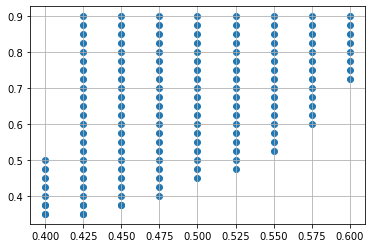

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 9
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  9 0.4500000000000001 0.3750000000000001
-------  18 0.4000000000000001 0.4500000000000002
-------  27 0.5000000000000002 0.4750000000000002
-------  36 0.4500000000000001 0.5250000000000002
-------  45 0.5250000000000001 0.5500000000000003
-------  54 0.4500000000000001 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  72 0.5500000000000003 0.6500000000000004
-------  81 0.4250000000000001 0.7000000000000004
-------  90 0.47500000000000014 0.7250000000000004
-------  99 0.5000000000000002 0.7500000000000004
-------  108 0.5250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  135 0.6000000000000003 0.8500000000000005
-------  144 0.4250000000000001 0.9000000000000006


In [12]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   9  18  27  36  45  54  63  72  81  90  99 108 117 126 135 144]


In [13]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  9 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  0 , total integrated cost =  13602.2666253313
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  18 0.4000000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4177.247133185956
Gradient descend method:  None
RUN  0 , total integrated cost =  4177.247133185956
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  27 0.5000000000000002 0.4750000000000002
set

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  2645.4206255778245
RUN  2 , total integrated cost =  1650.4857448323046
RUN  3 , total integrated cost =  1184.0857764355032
RUN  4 , total integrated cost =  1000.2236184865774
RUN  5 , total integrated cost =  854.6270392484131
RUN  6 , total integrated cost =  771.4560220697407
RUN  7 , total integrated cost =  765.2831244970236
RUN  8 , total integrated cost =  753.9191751828457
RUN  9 , total integrated cost =  750.2616554778762
RUN  10 , total integrated cost =  709.4291122594556
RUN  11 , total integrated cost =  702.5123597299354
RUN  12 , total integrated cost =  702.4998116930008
RUN  13 , total integrated cost =  702.4989913092355
RUN  14 , total integrated cost =  702.4988379251348
RUN  15 , total integrated cost 

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  702.4988304742634
RUN  18 , total integrated cost =  702.4988304742634
Control only changes marginally.
RUN  18 , total integrated cost =  702.4988304742634
Improved over  18  iterations in  20.599387491121888  seconds by  88.09809468484946  percent.
Problem in initial value trasfer:  Vmean_exc -63.120716047104764 -63.1537981740493
weight =  84.02016093398497
set cost params:  1.0 84.02016093398497 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5633.663142942799
Gradient descend method:  None
RUN  1 , total integrated cost =  5254.070109281189
RUN  2 , total integrated cost =  4640.149530182718
RUN  3 , total integrated cost =  4452.31972866224
RUN  4 , total integrated cost =  4448.124219168565
RUN  5 , total integrated cost =  4447.722912648864
RUN  6 , total integrated cost =  4447.139021567786
RUN  7 , total integrated cost =  4447.021434411485
RUN  8 , total integrated cost =  4447.021434411483
RUN  9 , total integrat

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  4447.021434411482
Control only changes marginally.
RUN  10 , total integrated cost =  4447.021434411482
Improved over  10  iterations in  0.6829624827951193  seconds by  21.06341253324321  percent.
Problem in initial value trasfer:  Vmean_exc -56.631520372069595 -56.63143717181941
-------  9 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  1 , total integrated cost =  10750.894116240966
RUN  2 , total integrated cost =  10685.498505017515
RUN  3 , total integrated cost =  10680.536812488714


...

Control only changes marginally.
RUN  59 , total integrated cost =  37801.59445194767
Improved over  59  iterations in  2.463987858965993  seconds by  2.3904599941021303  percent.
Problem in initial value trasfer:  Vmean_exc -56.7008965171764 -56.70084555092308
weight =  10.244900241713843
set cost params:  1.0 10.244900241713843 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37810.89982842778
Gradient descend method:  None
RUN  1 , total integrated cost =  37810.89982842778
Control only changes marginally.
RUN  1 , total integrated cost =  37810.89982842778
Improved over  1  iterations in  0.12487085536122322  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.7008965171764 -56.70084555092308
-------  144 0.4250000000000001 0.9000000000000006
set cost params:  1.0 0.0 0.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5467.915274789747
Gradient descend method:  None
RUN  1 , to

ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  4826.552612306741
Control only changes marginally.
RUN  6 , total integrated cost =  4826.552612306741
Improved over  6  iterations in  0.3782616890966892  seconds by  11.729564747282367  percent.
Problem in initial value trasfer:  Vmean_exc -56.623416420784466 -56.62339553488037
weight =  11.328821446693981
set cost params:  1.0 11.328821446693981 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4875.06363898742
Gradient descend method:  None
RUN  1 , total integrated cost =  4874.875914089538
RUN  2 , total integrated cost =  4874.875780479095


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  4874.875780479092
RUN  4 , total integrated cost =  4874.875780479088
RUN  5 , total integrated cost =  4874.875780479088
Control only changes marginally.
RUN  5 , total integrated cost =  4874.875780479088
Improved over  5  iterations in  0.3643072936683893  seconds by  0.003853457559614526  percent.
Problem in initial value trasfer:  Vmean_exc -56.62334791528316 -56.62332728804764


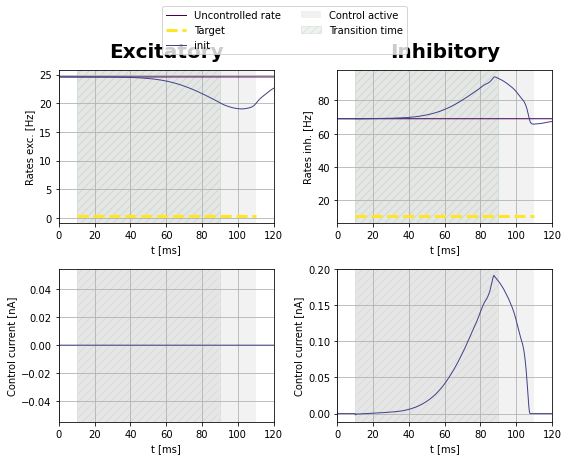

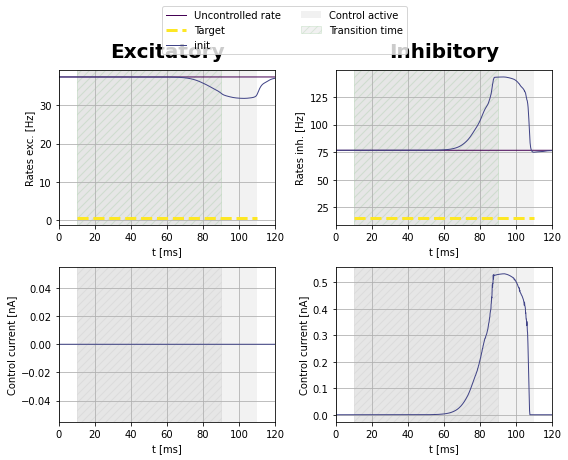

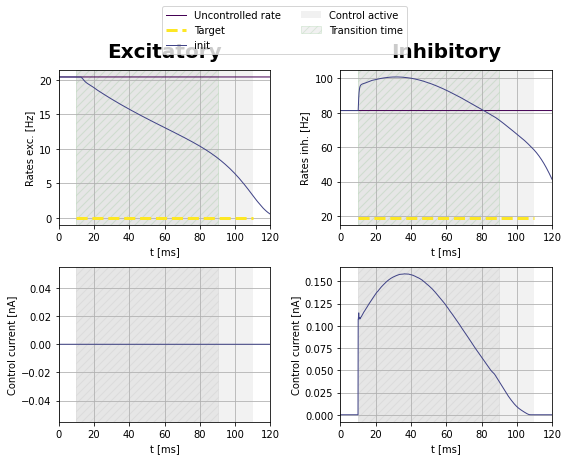

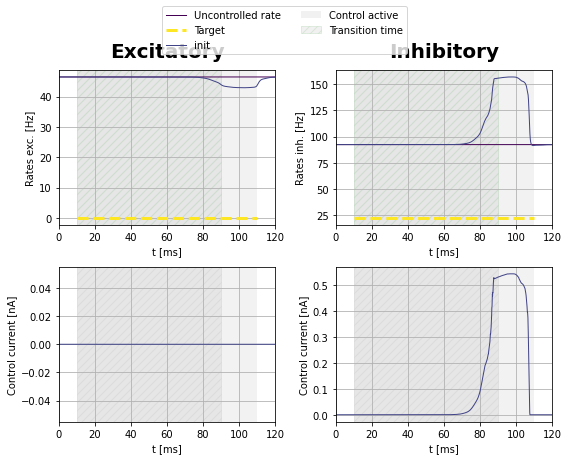

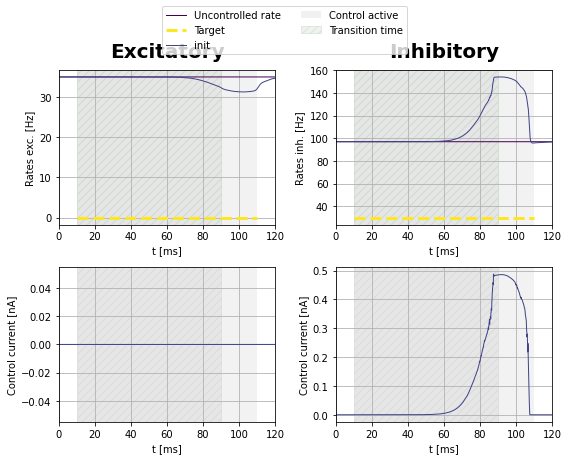

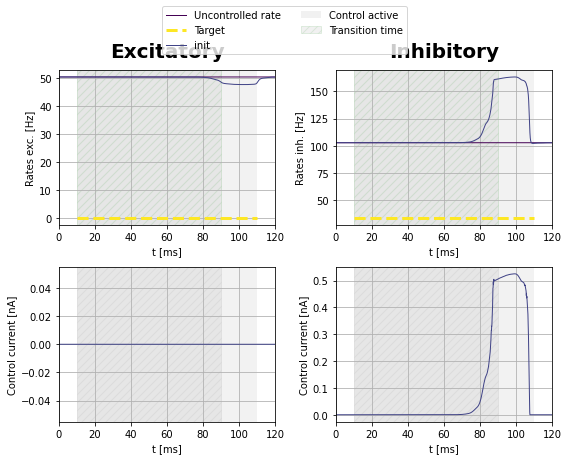

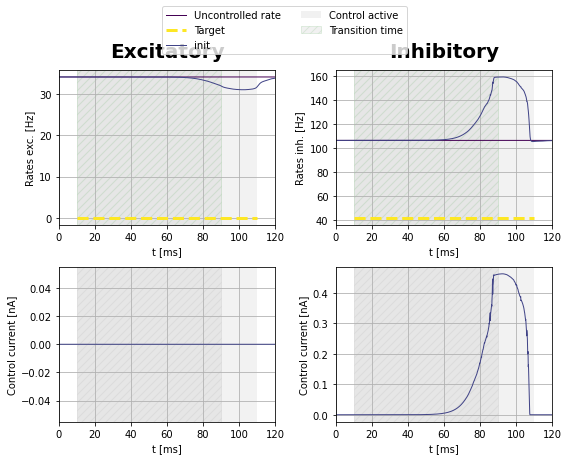

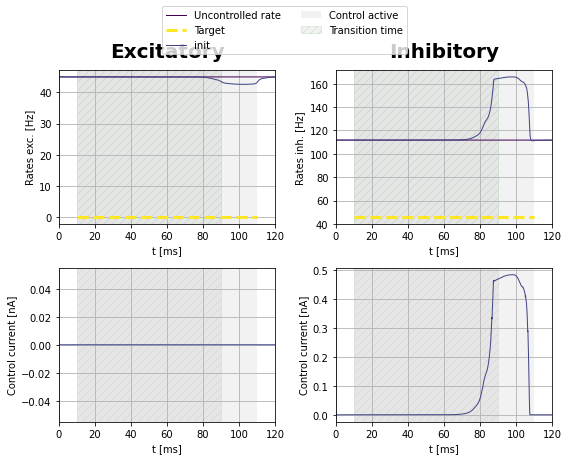

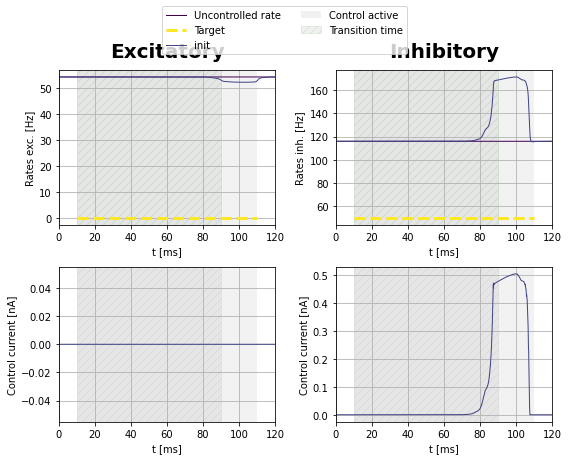

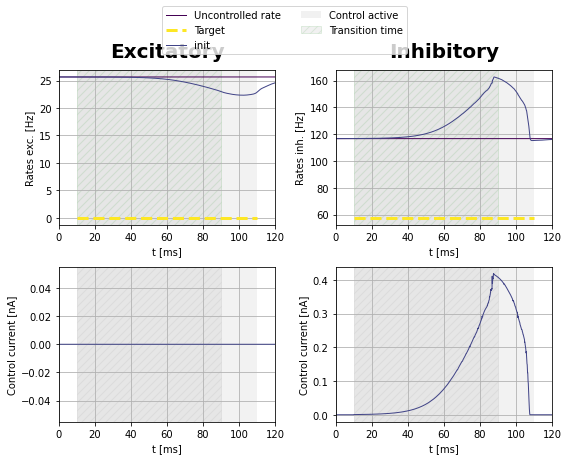

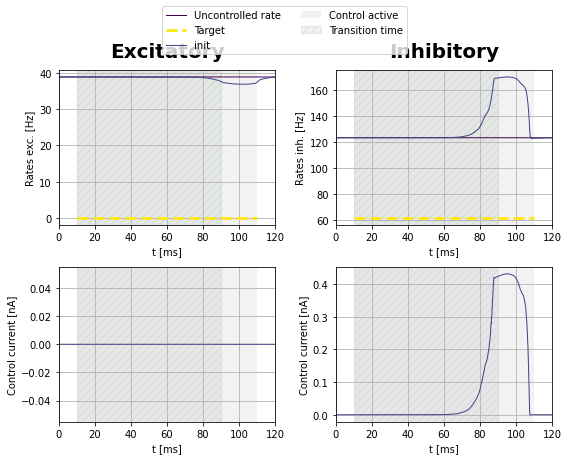

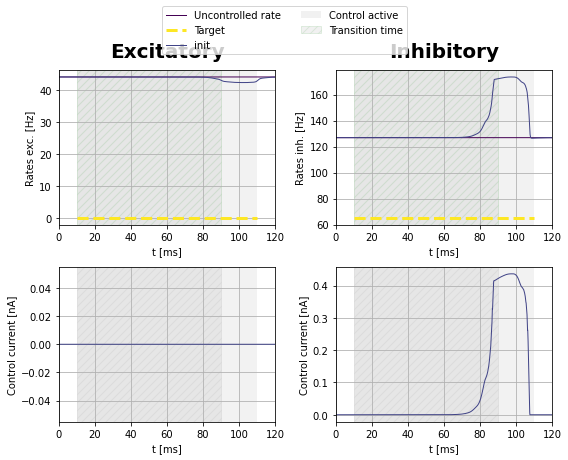

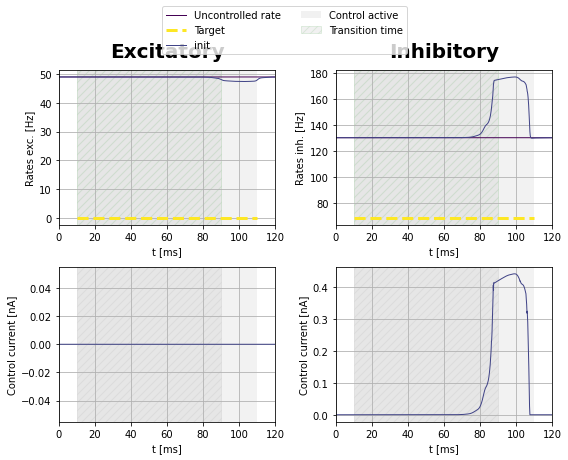

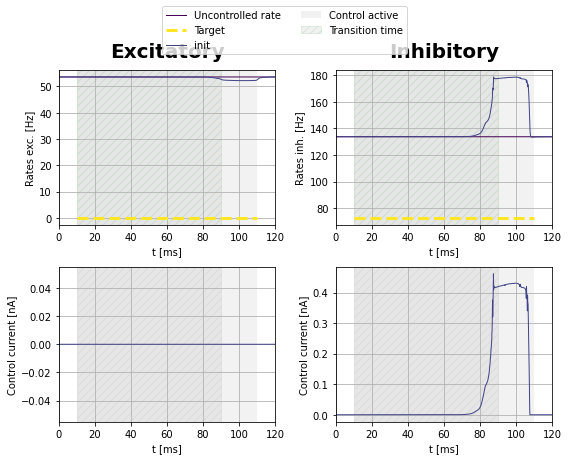

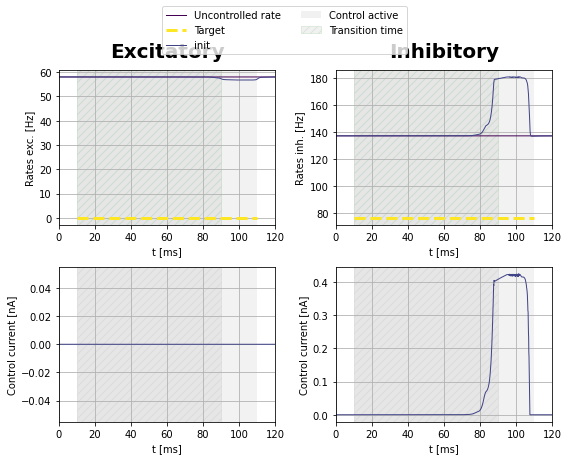

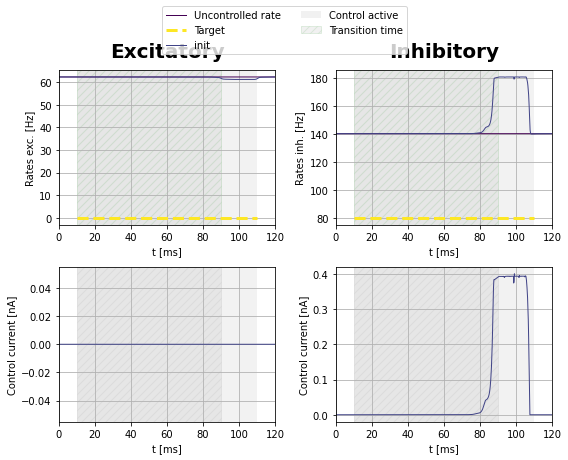

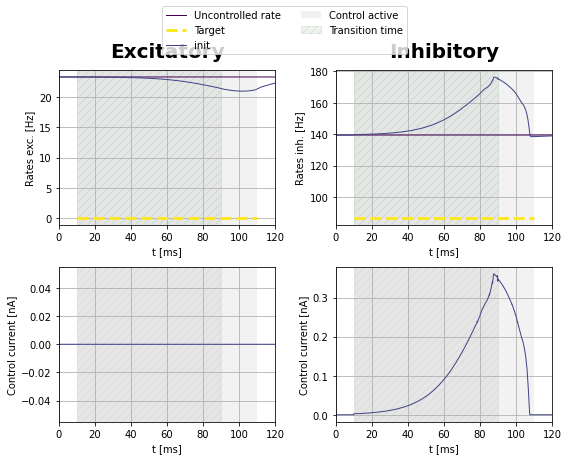

In [15]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
def getclosest(i, found_solution):
    if len(found_solution) == 0:
        print("no solutions found")
        return
    min_dist = np.sqrt((exc[i] - exc[found_solution[0]])**2 + (inh[i] - inh[found_solution[0]])**2)
    min_i = 0
    if i == 0:
        min_dist = np.sqrt((exc[i] - exc[1])**2 + (inh[i] - inh[1])**2)
        min_i = 1
    for i_ in found_solution[1:]:
        if i_ != i and i_ != min_i:
            dist_ = np.sqrt((exc[i] - exc[i_])**2 + (inh[i] - inh[i_])**2)
            if dist_ < min_dist:
                min_dist = dist_
                min_i = i_
    return min_i

found_solution = []
no_solution = []
last_update = -1

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
    
    if len(i_range) == len(found_solution):
        print("found solution for all parameters")
        break
    
    if last_update != k-1:
        print("no improvement from previous step")
        break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if i not in no_solution:
            print("no solution for ", i)
            no_solution.append(i)

        clostest_ = getclosest(i, found_solution)
        print("closest index ", clostest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        if i != 0:
            control0 = bestControl_init[clostest_][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  9 0.4500000000000001 0.3750000000000001
found solution for  9
-------  18 0.4000000000000001 0.4500000000000002
found solution for  18
-------  27 0.5000000000000002 0.4750000000000002
found solution for  27
-------  36 0.4500000000000001 0.5250000000000002
found solution for  36
-------  45 0.5250000000000001 0.5500000000000003
found solution for  45
-------  54 0.4500000000000001 0.6000000000000003
found solution for  54
-------  63 0.5000000000000002 0.6250000000000003
found solution for  63
-------  72 0.5500000000000003 0.6500000000000004
found solution for  72
-------  81 0.4250000000000001 0.7000000000000004
found solution for  81
-------  90 0.47500000000000014 0.7250000000000004
found solution for  90
-------  99 0.5000000000000002 0.7500000000000004
found

In [18]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
    
    print(conv_init[::i_stepsize])
    
    if all(conv == True for conv in conv_init[::i_stepsize][0]):
        if all(conv == True for conv in conv_init[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  70585.64256469779
set cost params:  1.0 70585.64256469779 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5899.133533115414
Gradient descend method:  None
RUN  1 , total integrated cost =  5899.1335292993945
RUN  2 , total integrated cost =  5899.133529296995
RUN  3 , total integrated cost =  5899.133529296991


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5899.133529296987
RUN  5 , total integrated cost =  5899.133529296983
RUN  6 , total integrated cost =  5899.133529296983
Control only changes marginally.
RUN  6 , total integrated cost =  5899.133529296983
Improved over  6  iterations in  0.34384172037243843  seconds by  6.472866687090573e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.62759759879953 -56.62759799972836
-------  9 0.4500000000000001 0.3750000000000001
no convergence
weight =  23054.191086434847
set cost params:  1.0 23054.191086434847 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13594.174718397462
Gradient descend method:  None
RUN  1 , total integrated cost =  13594.174715956216
RUN  2 , total integrated cost =  13594.174715955663


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  13594.174715955662
RUN  4 , total integrated cost =  13594.17471595566
RUN  5 , total integrated cost =  13594.17471595566
Control only changes marginally.
RUN  5 , total integrated cost =  13594.17471595566
Improved over  5  iterations in  0.18065249547362328  seconds by  1.7962122456083307e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.67600566123721 -56.6760074277389
-------  18 0.4000000000000001 0.4500000000000002
no convergence
weight =  61363.486138845416
set cost params:  1.0 61363.486138845416 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4174.936459810578
Gradient descend method:  None
RUN  1 , total integrated cost =  4174.936459146268


...

RUN  1 , total integrated cost =  11608.491910596302
RUN  2 , total integrated cost =  11608.491910596296
RUN  3 , total integrated cost =  11608.491910596296
Control only changes marginally.
RUN  3 , total integrated cost =  11608.491910596296
Improved over  3  iterations in  0.22661221213638783  seconds by  2.3707229956926312e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.66223587132404 -56.6622380752571
-------  63 0.5000000000000002 0.6250000000000003
converged for  63
-------  72 0.5500000000000003 0.6500000000000004
converged for  72
-------  81 0.4250000000000001 0.7000000000000004
no convergence
weight =  5222.627564211636
set cost params:  1.0 5222.627564211636 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6576.031309757616
Gradient descend method:  None
RUN  1 , total integrated cost =  6576.031308354431
RUN  2 , total integrated cost =  6576.031308354428


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  6576.031308354428
Control only changes marginally.
RUN  3 , total integrated cost =  6576.031308354428
Improved over  3  iterations in  0.24510451406240463  seconds by  2.1337925204534258e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.62807533996352 -56.628076033183824
-------  90 0.47500000000000014 0.7250000000000004
converged for  90
-------  99 0.5000000000000002 0.7500000000000004
converged for  99
-------  108 0.5250000000000001 0.7750000000000005
converged for  108
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  126 0.5750000000000002 0.8250000000000005
converged for  126
-------  135 0.6000000000000003 0.8500000000000005
converged for  135
-------  144 0.4250000000000001 0.9000000000000006
no convergence
weight =  1927.7201780496448
set cost params:  1.0 1927.7201780496448 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5462.068396047094
Gradient descend method:  None
RU

ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5462.068394332882
Control only changes marginally.
RUN  6 , total integrated cost =  5462.068394332882
Improved over  6  iterations in  0.3990493770688772  seconds by  3.1383933674078435e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.62281705811773 -56.62281729840731


In [19]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False]]


In [20]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [21]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.965230242219
Gradient descend method:  None
RUN  1 , total integrated cost =  38.70513825986489
RUN  2 , total integrated cost =  34.41780645303408
RUN  3 , total integrated cost =  29.419548725409047
RUN  4 , total integrated cost =  27.023313753693692
RUN  5 , total integrated cost =  24.43956604290539
RUN  6 , total integrated cost =  22.860732123144988
RUN  7 , total integrated cost =  21.237693652374077
RUN  8 , total integrated cost =  20.107496694182675
RUN  9 , total integrated cost =  18.933758994927977
RUN  10 , total integrated cost =  17.776569599883366
RUN  11 , total integrated cost =  16.315051825154978
RUN  12 , total integrated cost =  14.751250416775687
RUN  13 , total integrated cost =  13.191174059739653
RUN  14 , total integrated cost =  11.220658974634988
RUN  15 , total integrated cost =  11.166704880733153
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  199 , total integrated cost =  9.669601804287236
Improved over  199  iterations in  21.49519344046712  seconds by  99.83599628853493  percent.
Problem in initial value trasfer:  Vmean_exc -64.42591754609703 -64.41666239445483
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  43.991957787143086
Gradient descend method:  HS
RUN  1 , total integrated cost =  43.092923328225886
RUN  2 , total integrated cost =  42.23932743467191
RUN  3 , total integrated cost =  41.6711125532018
RUN  4 , total integrated cost =  41.54411119615969
RUN  5 , total integrated cost =  41.01789276485945
RUN  6 , total integrated cost =  40.765064993611595
RUN  7 , total integrated cost =  40.76506499361157
RUN  8 , total integrated cost =  40.66133286295715
RUN  9 , total integrated cost =  40.40602418910077
RUN  10 , total integrated cost =  40.40545469169534
RUN  11 , total integrated cost =  40.3972775075

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  40.24975183306801
Control only changes marginally.
RUN  18 , total integrated cost =  40.24975183306801
Improved over  18  iterations in  2.105920195579529  seconds by  8.506568341836243  percent.
Problem in initial value trasfer:  Vmean_exc -64.62762916153937 -64.62158433400428
weight =  14663.454339291455
set cost params:  1.0 14663.454339291455 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5814.419937921111
Gradient descend method:  None
RUN  1 , total integrated cost =  5553.406916055379
RUN  2 , total integrated cost =  5551.991634685206
RUN  3 , total integrated cost =  5230.279335308057
RUN  4 , total integrated cost =  4703.099737418257
RUN  5 , total integrated cost =  4699.576442869364
RUN  6 , total integrated cost =  4699.523052410439
RUN  7 , total integrated cost =  4699.522458829092
RUN  8 , total integrated cost =  4699.52244759008
RUN  9 , total integrated cost =  4699.522447351039
RUN  10 , total integra

...

Control only changes marginally.
RUN  52 , total integrated cost =  6.325327061740443
Improved over  52  iterations in  6.10398967191577  seconds by  99.88408756164299  percent.
Problem in initial value trasfer:  Vmean_exc -74.80998609467234 -74.85159389463801
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19.810862725671836
Gradient descend method:  HS
RUN  1 , total integrated cost =  19.567876006840947
RUN  2 , total integrated cost =  19.53522935526775
RUN  3 , total integrated cost =  19.52765918687273
RUN  4 , total integrated cost =  19.52765918687267
RUN  5 , total integrated cost =  19.527082520829875
RUN  6 , total integrated cost =  19.522828364599555
RUN  7 , total integrated cost =  19.52282040507422
RUN  8 , total integrated cost =  19.522807358885228
RUN  9 , total integrated cost =  19.52280735888518


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  19.522807358885167
RUN  11 , total integrated cost =  19.522807358885167
Control only changes marginally.
RUN  11 , total integrated cost =  19.522807358885167
Improved over  11  iterations in  1.1151279248297215  seconds by  1.4540273726362898  percent.
Problem in initial value trasfer:  Vmean_exc -73.82207127743706 -73.86832184800507
weight =  28006.832963127632
set cost params:  1.0 28006.832963127632 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5402.642028833626
Gradient descend method:  None
RUN  1 , total integrated cost =  4994.417643083695
RUN  2 , total integrated cost =  4994.417642074625
RUN  3 , total integrated cost =  4994.417642074614
RUN  4 , total integrated cost =  4994.417642074607
RUN  5 , total integrated cost =  4994.417642074598
RUN  6 , total integrated cost =  4994.417642074597


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  4994.417642074595
RUN  8 , total integrated cost =  4994.417642074595
Control only changes marginally.
RUN  8 , total integrated cost =  4994.417642074595
Improved over  8  iterations in  1.1807099748402834  seconds by  7.556013975761445  percent.
Problem in initial value trasfer:  Vmean_exc -62.7794471441263 -62.84224062872986


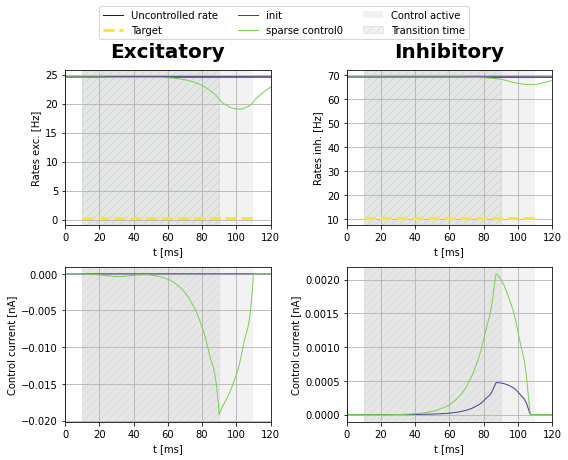

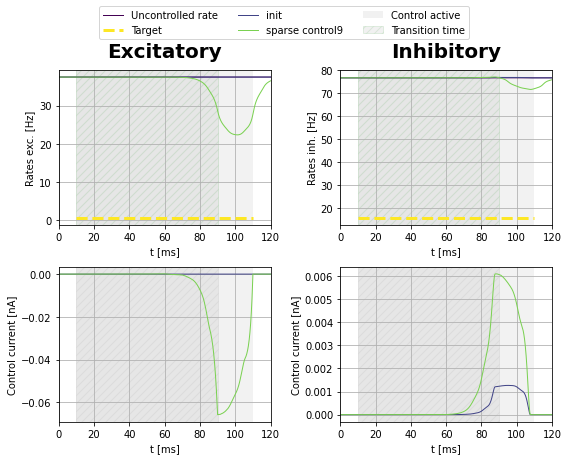

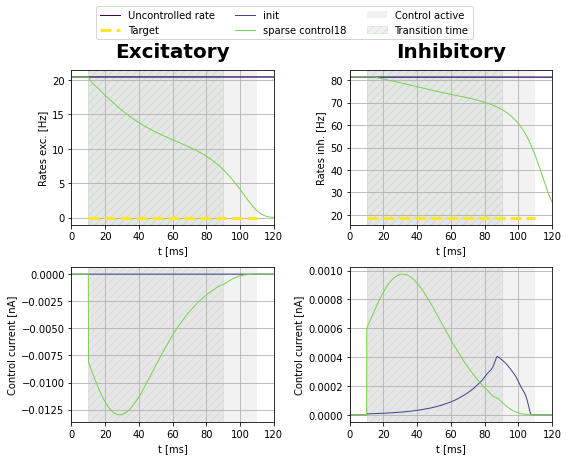

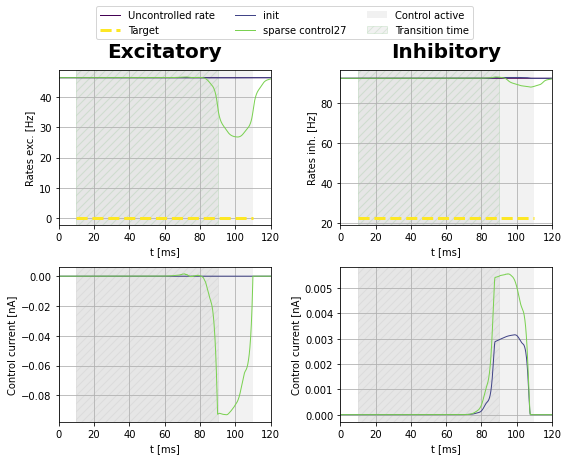

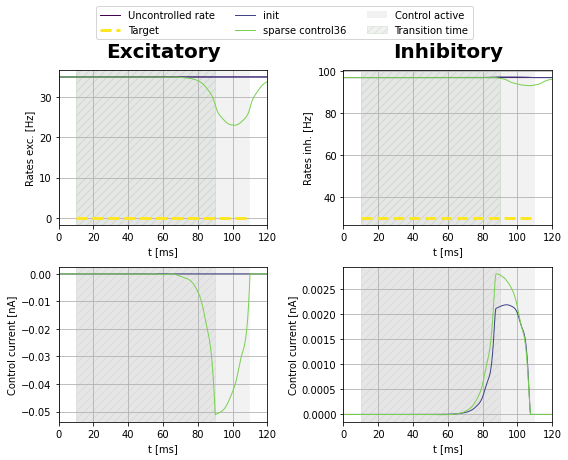

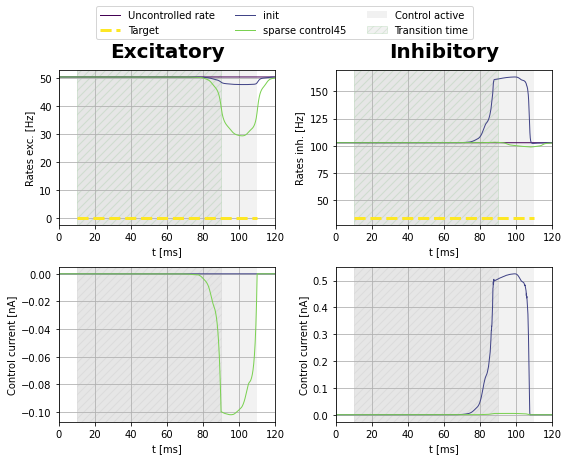

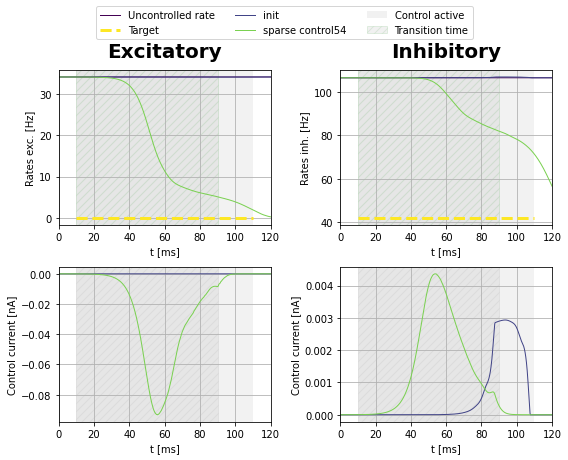

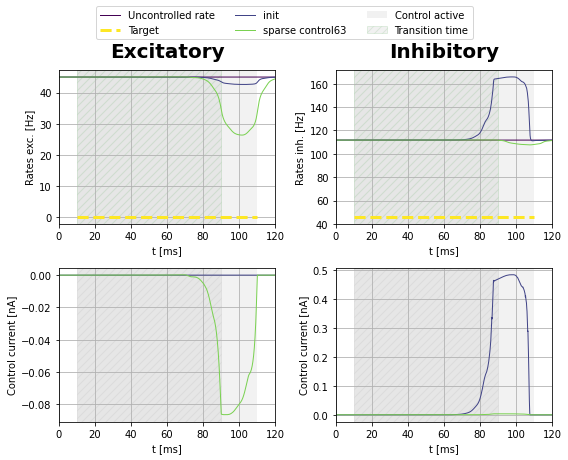

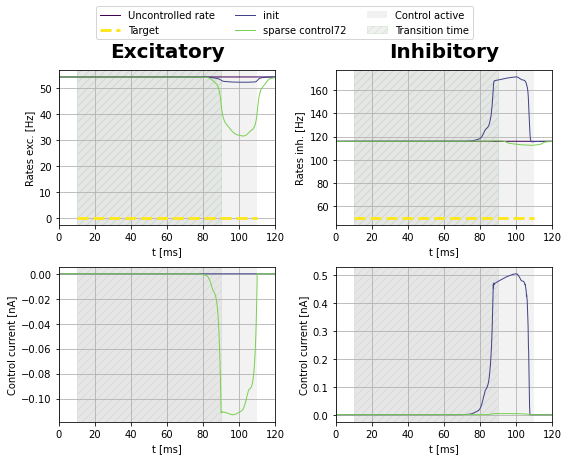

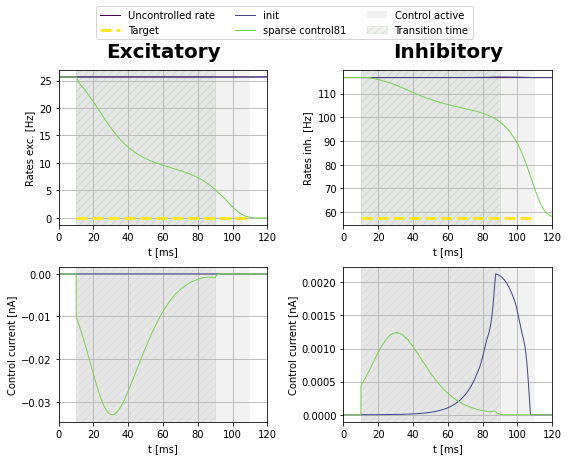

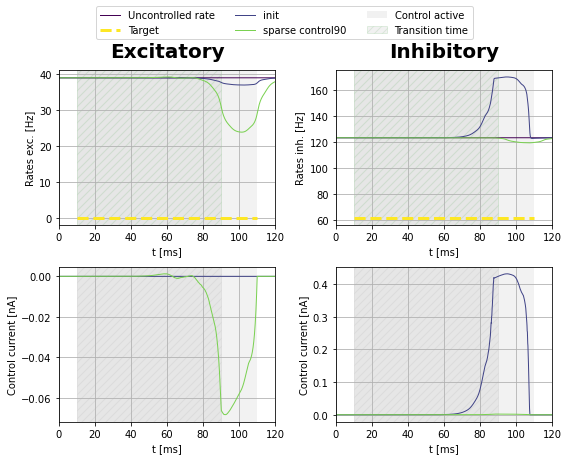

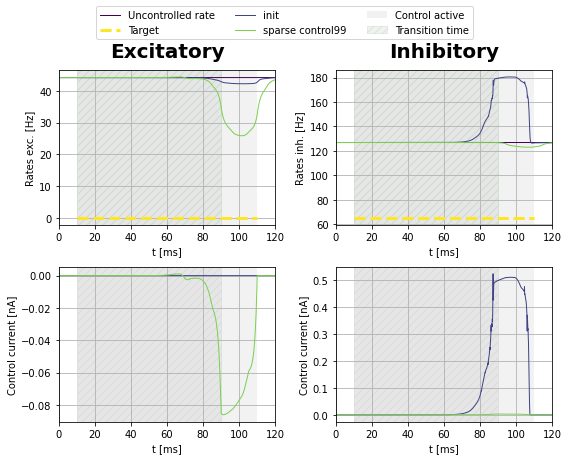

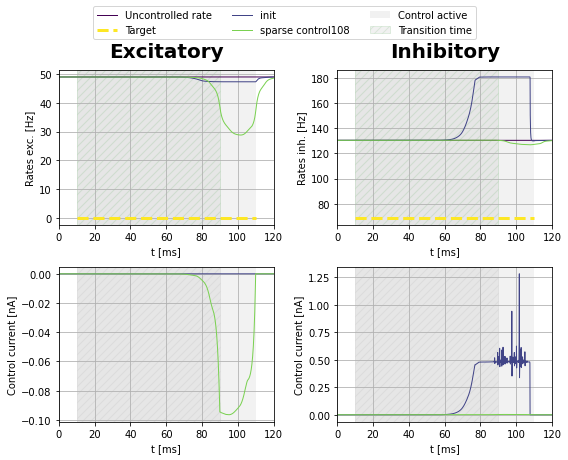

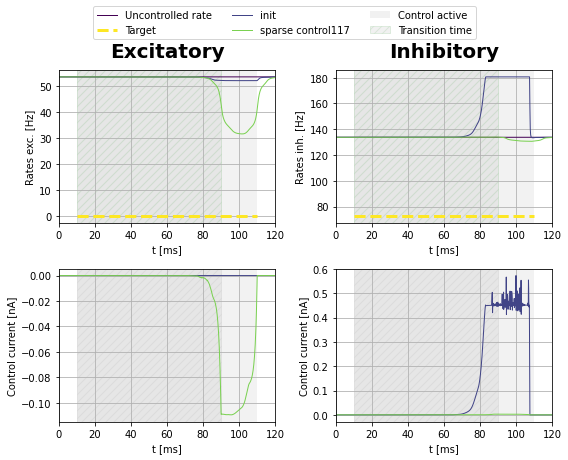

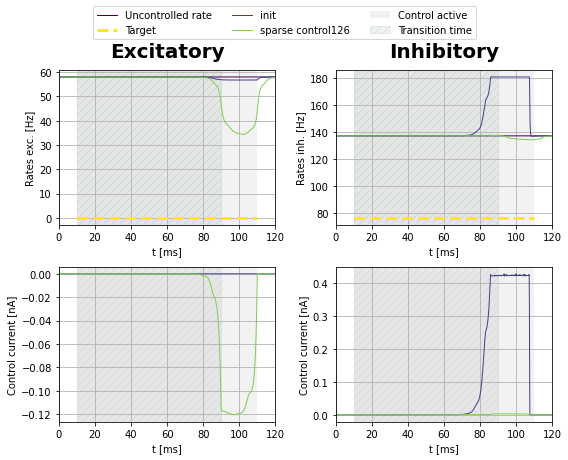

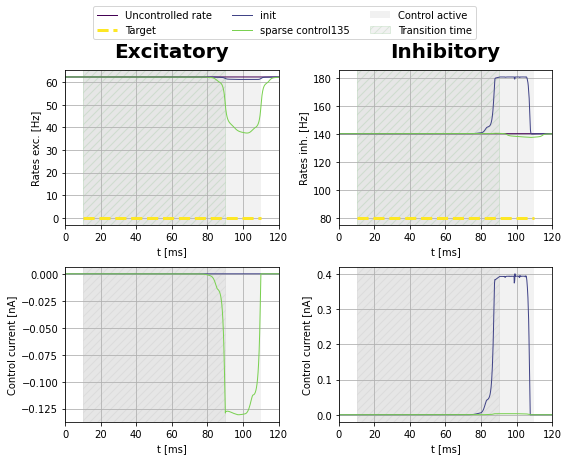

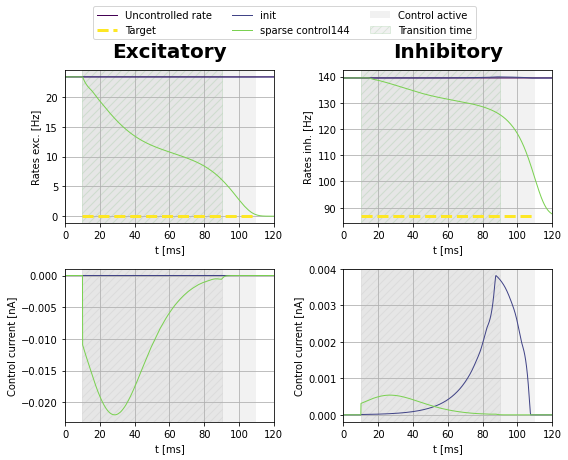

In [22]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [27]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    if all(conv == True for conv in conv_0[::i_stepsize][0]):
        if all(conv == True for conv in conv_0[::i_stepsize][1]):
            full_converge = True
            break

    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  184531.37484819052
set cost params:  1.0 184531.37484819052 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5802.4651794452
Gradient descend method:  None
RUN  1 , total integrated cost =  5802.434203498966
RUN  2 , total integrated cost =  5802.4342034989595
RUN  3 , total integrated cost =  5802.434203498959


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5802.434203498959
Control only changes marginally.
RUN  4 , total integrated cost =  5802.434203498959
Improved over  4  iterations in  0.9087414350360632  seconds by  0.0005338411396564879  percent.
Problem in initial value trasfer:  Vmean_exc -56.62696392576345 -56.62697575139213
-------  9 0.4500000000000001 0.3750000000000001
no convergence
weight =  96462.57333057947
set cost params:  1.0 96462.57333057947 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13362.053002290733
Gradient descend method:  None
RUN  1 , total integrated cost =  13361.973921281218
RUN  2 , total integrated cost =  13361.973921281215
RUN  3 , total integrated cost =  13361.973921281213


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  13361.973921281213
Control only changes marginally.
RUN  4 , total integrated cost =  13361.973921281213
Improved over  4  iterations in  0.9665760826319456  seconds by  0.0005918327782978849  percent.
Problem in initial value trasfer:  Vmean_exc -56.67456039618896 -56.67462570281852
-------  18 0.4000000000000001 0.4500000000000002
converged for  18
-------  27 0.5000000000000002 0.4750000000000002
no convergence
weight =  77492.22003457064
set cost params:  1.0 77492.22003457064 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21182.127778942948
Gradient descend method:  None
RUN  1 , total integrated cost =  21182.007139555666
RUN  2 , total integrated cost =  21182.007026148676
RUN  3 , total integrated cost =  21182.00702614867
RUN  4 , total integrated cost =  21182.007026148658


...

RUN  4 , total integrated cost =  28268.4997046753
Control only changes marginally.
RUN  4 , total integrated cost =  28268.4997046753
Improved over  4  iterations in  0.7991212941706181  seconds by  0.00040896920737054643  percent.
Problem in initial value trasfer:  Vmean_exc -56.70395242465632 -56.70396622248722
-------  126 0.5750000000000002 0.8250000000000005
no convergence
weight =  73096.88264773045
set cost params:  1.0 73096.88264773045 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33108.34406184763
Gradient descend method:  None
RUN  1 , total integrated cost =  33108.209657278894
RUN  2 , total integrated cost =  33108.20965314689
RUN  3 , total integrated cost =  33108.20965314531


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  33108.20965314531
Control only changes marginally.
RUN  4 , total integrated cost =  33108.20965314531
Improved over  4  iterations in  0.46671513095498085  seconds by  0.0004059662484650062  percent.
Problem in initial value trasfer:  Vmean_exc -56.70368213585137 -56.70366070175061
-------  135 0.6000000000000003 0.8500000000000005
no convergence
weight =  68946.16327581929
set cost params:  1.0 68946.16327581929 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38123.14448888329
Gradient descend method:  None
RUN  1 , total integrated cost =  38122.99995529579
RUN  2 , total integrated cost =  38122.99978142016
RUN  3 , total integrated cost =  38122.99978142012
RUN  4 , total integrated cost =  38122.99978142011


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  38122.9997814201
RUN  6 , total integrated cost =  38122.9997814201
Control only changes marginally.
RUN  6 , total integrated cost =  38122.9997814201
Improved over  6  iterations in  1.092524303123355  seconds by  0.00037957903298035944  percent.
Problem in initial value trasfer:  Vmean_exc -56.70079014118673 -56.700725737415794
-------  144 0.4250000000000001 0.9000000000000006
converged for  144
--------------- 11


In [26]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True]]
